
# What is Quantum Error Mitigation?

Quantum computers are extremely sensitive to noise.

Even tiny disturbances from:
- heat,
- electromagnetic interference,
- imperfect gates,
- imperfect measurements,
- or interactions with the environment

can introduce errors into a quantum computation.

Modern quantum computers are still noisy devices. They are often called:

**NISQ devices**  
(Noisy Intermediate-Scale Quantum devices)

Quantum Error Mitigation (QEM) tries to reduce the effect of noise **without fully correcting the errors**.

The goal is:

> estimate what the answer would have looked like if the quantum computer had less noise.

---

# Error mitigation vs error correction

Quantum error correction:
- uses many physical qubits,
- builds logical qubits,
- continuously detects and corrects errors,
- aims for fault-tolerant quantum computing.

Quantum error mitigation:
- does not fully protect the quantum state,
- uses extra experiments and classical post-processing,
- estimates cleaner results from noisy hardware.

---

# Simple real-life analogy

Imagine taking a photograph in foggy weather.

The picture becomes blurry because the environment adds noise.

You cannot perfectly recover the original scene, but image processing software can still improve the picture.

Quantum error mitigation works similarly.



# What is this notebook doing overall?

This notebook demonstrates important ideas used in modern quantum error mitigation research.

The notebook:
- creates Bell-state quantum circuits,
- simulates realistic quantum noise,
- measures how noise damages results,
- and applies mitigation methods to improve the estimated answer.

---

# Why use a Bell state?

A Bell state is one of the simplest examples of quantum entanglement.

The Bell state often looks like:

$
\frac{|00\rangle + |11\rangle}{\sqrt{2}}
$

This means:
- both qubits become strongly correlated,
- and measuring one qubit gives information about the other.

Bell states are useful because we already know what the ideal answer should look like.

This makes it easier to observe the effects of noise.


# Making Noisy Quantum Computers More Useful: A Hands-On Introduction to Quantum Error Mitigation with Qiskit

A thermometer gives noisy readings, so a careful scientist repeats the measurement and reports an average with uncertainty. A quantum computer also gives statistical data, but the noise can come from quantum gates, measurements, idle qubits, calibration drift, crosstalk, and unwanted coupling to the environment.

Many near-term quantum algorithms estimate **expectation values**: averages of many measurement outcomes. **Quantum error mitigation (QEM)** tries to reduce bias in those estimates by using extra experiments and classical post-processing.

QEM is different from quantum error correction. Error correction protects information by encoding it into larger logical qubits and correcting errors during the computation. Error mitigation does not correct every physical error. It tries to infer a better estimate of an ideal noiseless value from noisy data.

In this tutorial we will:

1. prepare a two-qubit Bell state;
2. estimate `ZZ`, `XX`, and `YY` correlations;
3. build a simple Qiskit Aer noise model;
4. implement readout error mitigation from first principles;
5. implement a small zero-noise extrapolation (ZNE) experiment;
6. add an optional IBM Runtime EstimatorV2 hardware section that is off by default.

The simulator sections run without IBM credentials.


## Dependencies

Validated package set:

```bash
python -m pip install qiskit==2.4.1 qiskit-aer==0.17.2 qiskit-ibm-runtime==0.47.0 numpy matplotlib pandas jupyter nbconvert pylatexenc
```

`pylatexenc` is only used to draw circuit diagrams with Matplotlib. The optional IBM section reads credentials from an environment variable and is disabled by default.


In [ ]:
!python -m pip install qiskit==2.4.1 qiskit-aer==0.17.2 qiskit-ibm-runtime==0.47.0 numpy matplotlib pandas jupyter nbconvert pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.8/386.8 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.2/108.2 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 85.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.0/218.0 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━

In [ ]:
from __future__ import annotations

from pathlib import Path
from typing import Mapping, Sequence
import importlib.metadata as metadata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, ReadoutError, depolarizing_error

SEED = 52
SHOTS = 4000
STATES_2Q = ("00", "01", "10", "11")
ROOT_DIR = Path.cwd()
if ROOT_DIR.name == "notebooks":
    ROOT_DIR = ROOT_DIR.parent
ASSET_DIR = ROOT_DIR / "assets/images/qem-basics"
ASSET_DIR.mkdir(parents=True, exist_ok=True)

for package in ["qiskit", "qiskit-aer", "qiskit-ibm-runtime", "numpy", "matplotlib", "pandas"]:
    print(f"{package}: {metadata.version(package)}")


qiskit: 2.4.1
qiskit-aer: 0.17.2
qiskit-ibm-runtime: 0.47.0
numpy: 2.0.2
matplotlib: 3.10.0
pandas: 2.2.2


## 1. A tiny observable-estimation problem

We use the Bell state

$$
|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}.
$$

This state has simple ideal answers:

$$
\langle ZZ\rangle = 1, \quad \langle XX\rangle = 1, \quad \langle YY\rangle = -1.
$$

The symbols `X`, `Y`, and `Z` are Pauli observables. A value near `1` means the two signs usually agree. A value near `-1` means the signs usually disagree. A value near `0` means the correlation has mostly disappeared.


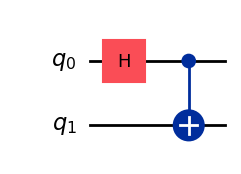

In [ ]:
def make_bell_circuit() -> QuantumCircuit:
    circuit = QuantumCircuit(2, name="bell_phi_plus")
    circuit.h(0)
    circuit.cx(0, 1)
    return circuit


def make_observable_circuit(observable: str) -> QuantumCircuit:
    """Return a Bell-state circuit measured in the basis for a two-qubit Pauli observable."""
    observable = observable.upper()
    if len(observable) != 2 or any(symbol not in "IXYZ" for symbol in observable):
        raise ValueError("Use a two-character observable made from I, X, Y, and Z.")

    circuit = make_bell_circuit()
    circuit.name = f"measure_{observable}"
    for qubit, pauli in enumerate(reversed(observable)):
        if pauli == "X":
            circuit.h(qubit)
        elif pauli == "Y":
            circuit.sdg(qubit)
            circuit.h(qubit)
    circuit.measure_all()
    return circuit


bell = make_bell_circuit()
zz_circuit = make_observable_circuit("ZZ")
xx_circuit = make_observable_circuit("XX")
yy_circuit = make_observable_circuit("YY")

fig = bell.draw(output="mpl")
fig.savefig(ASSET_DIR / "qem_bell_circuit.png", bbox_inches="tight", dpi=160)
plt.close(fig)

bell.draw(output="mpl")


The Bell circuit has one Hadamard gate and one controlled-NOT gate. The measurement basis rotations are added separately for each observable.


## 2. Noisy simulation with Qiskit Aer

The next noise model is intentionally small. It includes depolarizing noise after one-qubit gates, stronger depolarizing noise after the two-qubit gate, and readout error during measurement. It is a teaching model, not a hardware claim.


In [ ]:
def build_simple_noise_model(
    one_qubit_depol: float = 0.002,
    two_qubit_depol: float = 0.02,
    readout_p0_to_1: float = 0.03,
    readout_p1_to_0: float = 0.05,
) -> NoiseModel:
    for value in (one_qubit_depol, two_qubit_depol, readout_p0_to_1, readout_p1_to_0):
        if not 0 <= value < 1:
            raise ValueError("Noise probabilities must be in [0, 1).")

    noise_model = NoiseModel()
    if one_qubit_depol:
        one_error = depolarizing_error(one_qubit_depol, 1)
        noise_model.add_all_qubit_quantum_error(one_error, ["h", "x", "sx", "s", "sdg"])
    if two_qubit_depol:
        two_error = depolarizing_error(two_qubit_depol, 2)
        noise_model.add_all_qubit_quantum_error(two_error, ["cx"])
    if readout_p0_to_1 or readout_p1_to_0:
        readout_error = ReadoutError(
            [[1 - readout_p0_to_1, readout_p0_to_1], [readout_p1_to_0, 1 - readout_p1_to_0]]
        )
        noise_model.add_all_qubit_readout_error(readout_error)
    return noise_model


def run_aer_counts(
    circuits: QuantumCircuit | Sequence[QuantumCircuit],
    shots: int = SHOTS,
    noise_model: NoiseModel | None = None,
    seed: int = SEED,
) -> list[dict[str, int]]:
    if isinstance(circuits, QuantumCircuit):
        circuits = [circuits]
    simulator = AerSimulator(noise_model=noise_model, seed_simulator=seed)
    result = simulator.run(list(circuits), shots=shots).result()
    return [dict(result.get_counts(index)) for index in range(len(circuits))]


def shots_from_counts(counts: Mapping[str, int]) -> int:
    shots = int(sum(counts.values()))
    if shots <= 0:
        raise ValueError("Counts must contain at least one shot.")
    return shots


def counts_to_probability_vector(counts: Mapping[str, int], states: Sequence[str] = STATES_2Q) -> np.ndarray:
    shots = shots_from_counts(counts)
    return np.array([counts.get(state, 0) / shots for state in states], dtype=float)


def counts_to_expectation_zz(counts: Mapping[str, int]) -> float:
    shots = shots_from_counts(counts)
    total = 0
    for bitstring, count in counts.items():
        total += (1 if bitstring in ("00", "11") else -1) * count
    return total / shots


def expectation_uncertainty(expectation: float, shots: int) -> float:
    variance = max(0.0, 1.0 - expectation**2)
    return float(np.sqrt(variance / shots))


noise_model = build_simple_noise_model()
observable_circuits = [zz_circuit, xx_circuit, yy_circuit]
observables = ["ZZ", "XX", "YY"]

ideal_counts = run_aer_counts(observable_circuits, shots=SHOTS, noise_model=None, seed=SEED)
noisy_counts = run_aer_counts(observable_circuits, shots=SHOTS, noise_model=noise_model, seed=SEED)

ideal_expectations = np.array([counts_to_expectation_zz(counts) for counts in ideal_counts])
raw_expectations = np.array([counts_to_expectation_zz(counts) for counts in noisy_counts])
raw_uncertainties = np.array([
    expectation_uncertainty(value, shots_from_counts(counts))
    for value, counts in zip(raw_expectations, noisy_counts)
])

assert np.allclose(ideal_expectations, np.array([1.0, 1.0, -1.0]))

pd.DataFrame({
    "observable": observables,
    "ideal": ideal_expectations,
    "raw noisy": raw_expectations,
    "raw standard error": raw_uncertainties,
})


,observable,ideal,raw noisy,raw standard error
0,ZZ,1.0,0.8295,0.008831
1,XX,1.0,0.8255,0.008924
2,YY,-1.0,-0.8235,0.008970


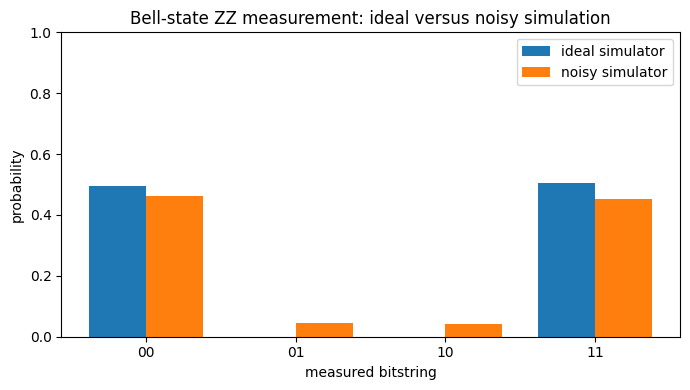

In [ ]:
states = list(STATES_2Q)
ideal_probs = counts_to_probability_vector(ideal_counts[0])
noisy_probs = counts_to_probability_vector(noisy_counts[0])
x = np.arange(len(states))
width = 0.38
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - width / 2, ideal_probs, width, label="ideal simulator")
ax.bar(x + width / 2, noisy_probs, width, label="noisy simulator")
ax.set_xticks(x)
ax.set_xticklabels(states)
ax.set_ylim(0, 1)
ax.set_ylabel("probability")
ax.set_xlabel("measured bitstring")
ax.set_title("Bell-state ZZ measurement: ideal versus noisy simulation")
ax.legend()
fig.tight_layout()
fig.savefig(ASSET_DIR / "qem_noisy_vs_ideal_histogram.png", dpi=160)
plt.show()


The ideal `ZZ` measurement only returns `00` and `11`. In the noisy run, `01` and `10` appear, and the expectation value is pulled toward zero.


## 3. Readout error mitigation from first principles

Readout error means the measurement device can report the wrong classical bit. We estimate this error using calibration circuits:

1. prepare `00`, `01`, `10`, and `11`;
2. measure each state many times;
3. build an assignment matrix whose columns describe reported outcomes for each prepared state;
4. invert the matrix and apply it to noisy probability vectors.

The inverse can amplify noise, so the helper below clips small negative probabilities from finite-shot noise and renormalizes.


In [ ]:
def make_readout_calibration_circuit(state: str) -> QuantumCircuit:
    if state not in STATES_2Q:
        raise ValueError("Use one of '00', '01', '10', or '11'.")
    circuit = QuantumCircuit(2, name=f"cal_{state}")
    if state[1] == "1":
        circuit.x(0)
    if state[0] == "1":
        circuit.x(1)
    circuit.measure_all()
    return circuit


def estimate_assignment_matrix(noise_model: NoiseModel, shots: int = SHOTS, seed: int = SEED + 100) -> np.ndarray:
    calibration_circuits = [make_readout_calibration_circuit(state) for state in STATES_2Q]
    calibration_counts = run_aer_counts(calibration_circuits, shots=shots, noise_model=noise_model, seed=seed)
    matrix = np.zeros((4, 4))
    for column, counts in enumerate(calibration_counts):
        matrix[:, column] = counts_to_probability_vector(counts)
    assert np.allclose(matrix.sum(axis=0), np.ones(4), atol=1e-12)
    return matrix


def apply_readout_mitigation(counts: Mapping[str, int], assignment_matrix: np.ndarray) -> np.ndarray:
    observed = counts_to_probability_vector(counts)
    corrected = np.linalg.pinv(assignment_matrix) @ observed
    corrected = np.clip(corrected, 0.0, None)
    total = corrected.sum()
    if total <= 0:
        raise ValueError("Corrected probabilities vanished after clipping.")
    return corrected / total


def probabilities_to_expectation_zz(probabilities: Sequence[float]) -> float:
    probabilities = np.asarray(probabilities, dtype=float)
    if probabilities.shape != (4,):
        raise ValueError("Expected four probabilities ordered as 00, 01, 10, 11.")
    return float(np.array([1.0, -1.0, -1.0, 1.0]) @ probabilities)


assignment_matrix = estimate_assignment_matrix(noise_model)
print("Assignment matrix condition number:", round(float(np.linalg.cond(assignment_matrix)), 3))

readout_mitigated_probabilities = [apply_readout_mitigation(counts, assignment_matrix) for counts in noisy_counts]
readout_mitigated_expectations = np.array([
    probabilities_to_expectation_zz(probs) for probs in readout_mitigated_probabilities
])

pd.DataFrame(
    assignment_matrix,
    index=[f"reported {state}" for state in STATES_2Q],
    columns=[f"prepared {state}" for state in STATES_2Q],
)


Assignment matrix condition number: 1.194


,prepared 00,prepared 01,prepared 10,prepared 11
reported 00,0.94225,0.04800,0.04675,0.00275
reported 01,0.02700,0.91975,0.00225,0.05075
reported 10,0.03050,0.00150,0.92225,0.04950
reported 11,0.00025,0.03075,0.02875,0.89700


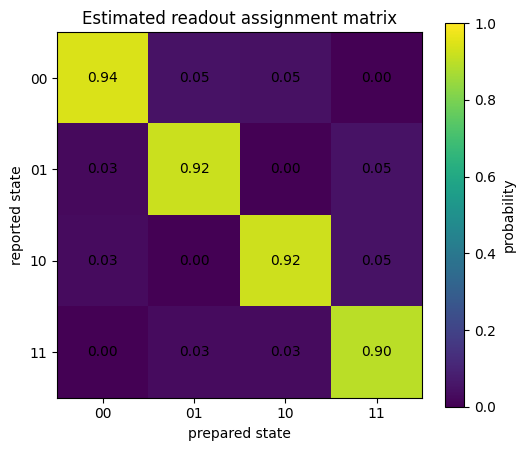

In [ ]:
fig, ax = plt.subplots(figsize=(5.4, 4.6))
image = ax.imshow(assignment_matrix, vmin=0, vmax=1)
ax.set_xticks(np.arange(4))
ax.set_yticks(np.arange(4))
ax.set_xticklabels(STATES_2Q)
ax.set_yticklabels(STATES_2Q)
ax.set_xlabel("prepared state")
ax.set_ylabel("reported state")
ax.set_title("Estimated readout assignment matrix")
for row in range(4):
    for col in range(4):
        ax.text(col, row, f"{assignment_matrix[row, col]:.2f}", ha="center", va="center")
fig.colorbar(image, ax=ax, label="probability")
fig.tight_layout()
fig.savefig(ASSET_DIR / "qem_readout_assignment_matrix.png", dpi=160)
plt.show()


In [ ]:
mitigation_table = pd.DataFrame({
    "observable": observables,
    "ideal": ideal_expectations,
    "raw noisy": raw_expectations,
    "readout mitigated": readout_mitigated_expectations,
})
mitigation_table["raw absolute error"] = np.abs(mitigation_table["raw noisy"] - mitigation_table["ideal"])
mitigation_table["mitigated absolute error"] = np.abs(mitigation_table["readout mitigated"] - mitigation_table["ideal"])
mitigation_table


,observable,ideal,raw noisy,readout mitigated,raw absolute error,mitigated absolute error
0,ZZ,1.0,0.8295,0.985484,0.1705,0.014516
1,XX,1.0,0.8255,0.978292,0.1745,0.021708
2,YY,-1.0,-0.8235,-0.974283,0.1765,0.025717


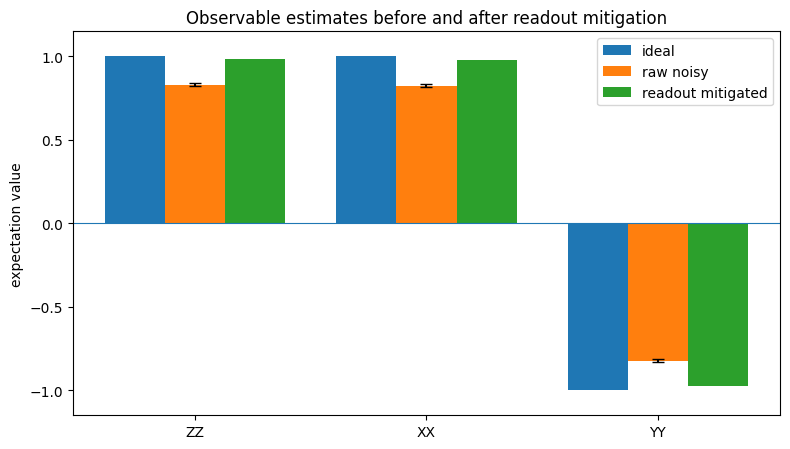

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.6))
positions = np.arange(len(observables))
width = 0.26
ax.bar(positions - width, ideal_expectations, width, label="ideal")
ax.bar(positions, raw_expectations, width, yerr=raw_uncertainties, capsize=4, label="raw noisy")
ax.bar(positions + width, readout_mitigated_expectations, width, label="readout mitigated")
ax.axhline(0, linewidth=0.8)
ax.set_xticks(positions)
ax.set_xticklabels(observables)
ax.set_ylim(-1.15, 1.15)
ax.set_ylabel("expectation value")
ax.set_title("Observable estimates before and after readout mitigation")
ax.legend()
fig.tight_layout()
fig.savefig(ASSET_DIR / "qem_raw_vs_readout_mitigated.png", dpi=160)
plt.show()


Readout mitigation moves the estimates closer to the ideal values because a large part of this teaching noise model is measurement error. The cost is extra calibration shots.


## 4. Zero-noise extrapolation

ZNE estimates the value at zero noise by first running noisier versions of the same ideal circuit. A digital way to increase noise is gate folding. Ideally, `U U† U` acts like `U`, but it uses more gates and therefore usually suffers more noise.

We fold the Bell circuit with noise factors 1, 3, and 5, fit a line, and evaluate that line at noise factor 0. This can help, but it can also fail if the trend is not smooth or if finite-shot noise is too large.


In [ ]:
def fold_circuit_for_zne(circuit: QuantumCircuit, noise_factor: int) -> QuantumCircuit:
    if noise_factor not in (1, 3, 5):
        raise ValueError("This tutorial uses odd noise factors 1, 3, and 5.")
    repetitions = (noise_factor - 1) // 2
    folded = QuantumCircuit(circuit.num_qubits, name=f"{circuit.name}_fold_{noise_factor}")
    for instruction in circuit.data:
        operation = instruction.operation
        qubits = [circuit.find_bit(qubit).index for qubit in instruction.qubits]
        clbits = [circuit.find_bit(clbit).index for clbit in instruction.clbits]
        if operation.name in {"measure", "barrier"}:
            continue
        folded.append(operation, qubits, clbits)
        for _ in range(repetitions):
            folded.append(operation.inverse(), qubits, clbits)
            folded.append(operation, qubits, clbits)
    return folded


def add_measurements_to_folded_circuit(folded: QuantumCircuit, observable: str) -> QuantumCircuit:
    measured = folded.copy(name=f"{folded.name}_measure_{observable}")
    for qubit, pauli in enumerate(reversed(observable.upper())):
        if pauli == "X":
            measured.h(qubit)
        elif pauli == "Y":
            measured.sdg(qubit)
            measured.h(qubit)
    measured.measure_all()
    return measured


def fit_zero_noise_limit(noise_factors: Sequence[float], expectations: Sequence[float]) -> tuple[float, np.ndarray]:
    coefficients = np.polyfit(np.asarray(noise_factors, dtype=float), np.asarray(expectations, dtype=float), deg=1)
    return float(np.poly1d(coefficients)(0.0)), coefficients


noise_factors = np.array([1, 3, 5])
folded_zz_circuits = [
    add_measurements_to_folded_circuit(fold_circuit_for_zne(make_bell_circuit(), factor), "ZZ")
    for factor in noise_factors
]
folded_zz_counts = run_aer_counts(folded_zz_circuits, shots=SHOTS, noise_model=noise_model, seed=SEED + 200)

zne_raw_expectations = np.array([counts_to_expectation_zz(counts) for counts in folded_zz_counts])
zne_readout_expectations = np.array([
    probabilities_to_expectation_zz(apply_readout_mitigation(counts, assignment_matrix))
    for counts in folded_zz_counts
])

zne_raw_limit, zne_raw_coefficients = fit_zero_noise_limit(noise_factors, zne_raw_expectations)
zne_readout_limit, zne_readout_coefficients = fit_zero_noise_limit(noise_factors, zne_readout_expectations)

pd.DataFrame({
    "noise factor": noise_factors,
    "raw ZZ": zne_raw_expectations,
    "readout-mitigated ZZ": zne_readout_expectations,
})


,noise factor,raw ZZ,readout-mitigated ZZ
0,1,0.8245,0.977740
1,3,0.8065,0.956543
2,5,0.7750,0.919361


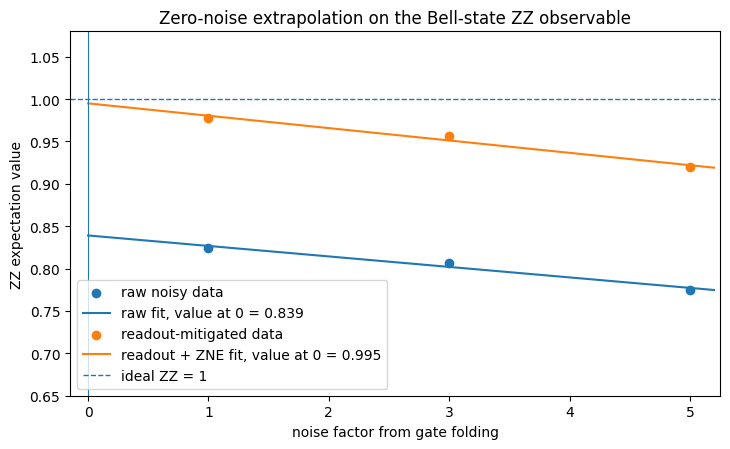

Raw noisy ZZ at factor 1: 0.825
ZNE-only zero-noise estimate: 0.839
Readout + ZNE zero-noise estimate: 0.995


In [ ]:
fit_x = np.linspace(0, 5.2, 100)
raw_fit = np.poly1d(zne_raw_coefficients)(fit_x)
readout_fit = np.poly1d(zne_readout_coefficients)(fit_x)
fig, ax = plt.subplots(figsize=(7.4, 4.6))
ax.scatter(noise_factors, zne_raw_expectations, label="raw noisy data")
ax.plot(fit_x, raw_fit, label=f"raw fit, value at 0 = {zne_raw_limit:.3f}")
ax.scatter(noise_factors, zne_readout_expectations, label="readout-mitigated data")
ax.plot(fit_x, readout_fit, label=f"readout + ZNE fit, value at 0 = {zne_readout_limit:.3f}")
ax.axhline(1.0, linestyle="--", linewidth=1.0, label="ideal ZZ = 1")
ax.axvline(0.0, linewidth=0.8)
ax.set_xlim(-0.15, 5.25)
ax.set_ylim(0.65, 1.08)
ax.set_xlabel("noise factor from gate folding")
ax.set_ylabel("ZZ expectation value")
ax.set_title("Zero-noise extrapolation on the Bell-state ZZ observable")
ax.legend(loc="lower left")
fig.tight_layout()
fig.savefig(ASSET_DIR / "qem_zne_extrapolation.png", dpi=160)
plt.show()

print(f"Raw noisy ZZ at factor 1: {zne_raw_expectations[0]:.3f}")
print(f"ZNE-only zero-noise estimate: {zne_raw_limit:.3f}")
print(f"Readout + ZNE zero-noise estimate: {zne_readout_limit:.3f}")


Here ZNE improves the gate-noise part of the estimate, while readout mitigation handles measurement bias. The combined estimate can overshoot the ideal value because it is still an extrapolated finite-shot estimate.


## 5. A miniature version of a modern QEM workflow

Modern QEM studies estimate observables from noisy hardware, amplify noise deliberately, extrapolate toward the zero-noise limit, use measurement mitigation, and report overhead. The next simulator-only benchmark reproduces that pattern on the smallest scale: one Bell-state observable with several noise strengths.


In [ ]:
def estimate_zz_with_methods(noise_model: NoiseModel, shots: int, seed: int) -> dict[str, float]:
    assignment = estimate_assignment_matrix(noise_model, shots=shots, seed=seed + 10)
    base_counts = run_aer_counts(make_observable_circuit("ZZ"), shots=shots, noise_model=noise_model, seed=seed + 20)[0]
    raw = counts_to_expectation_zz(base_counts)
    readout = probabilities_to_expectation_zz(apply_readout_mitigation(base_counts, assignment))

    folded = [
        add_measurements_to_folded_circuit(fold_circuit_for_zne(make_bell_circuit(), factor), "ZZ")
        for factor in noise_factors
    ]
    folded_counts = run_aer_counts(folded, shots=shots, noise_model=noise_model, seed=seed + 30)
    folded_raw = np.array([counts_to_expectation_zz(counts) for counts in folded_counts])
    folded_readout = np.array([
        probabilities_to_expectation_zz(apply_readout_mitigation(counts, assignment))
        for counts in folded_counts
    ])
    zne, _ = fit_zero_noise_limit(noise_factors, folded_raw)
    readout_zne, _ = fit_zero_noise_limit(noise_factors, folded_readout)
    return {"raw": raw, "readout": readout, "ZNE": zne, "readout + ZNE": readout_zne}


benchmark_rows = []
for index, two_qubit_depol in enumerate([0.002, 0.015, 0.04, 0.08]):
    model = build_simple_noise_model(
        one_qubit_depol=0.0015,
        two_qubit_depol=two_qubit_depol,
        readout_p0_to_1=0.03,
        readout_p1_to_0=0.05,
    )
    estimates = estimate_zz_with_methods(model, shots=1500, seed=SEED + 400 + index)
    for method, estimate in estimates.items():
        benchmark_rows.append({
            "two-qubit depolarizing probability": two_qubit_depol,
            "method": method,
            "ZZ estimate": estimate,
            "absolute error from ideal": abs(estimate - 1.0),
        })

benchmark_df = pd.DataFrame(benchmark_rows)
benchmark_df


,two-qubit depolarizing probability,method,ZZ estimate,absolute error from ideal
0,0.002,raw,0.869333,1.306667e-01
1,0.002,readout,1.000000,0.000000e+00
2,0.002,ZNE,0.822889,1.771111e-01
3,0.002,readout + ZNE,0.974534,2.546611e-02
4,0.015,raw,0.852000,1.480000e-01
5,0.015,readout,0.990178,9.821877e-03
6,0.015,ZNE,0.839111,1.608889e-01
7,0.015,readout + ZNE,0.978115,2.188469e-02
8,0.040,raw,0.849333,1.506667e-01
9,0.040,readout,1.000000,2.220446e-16


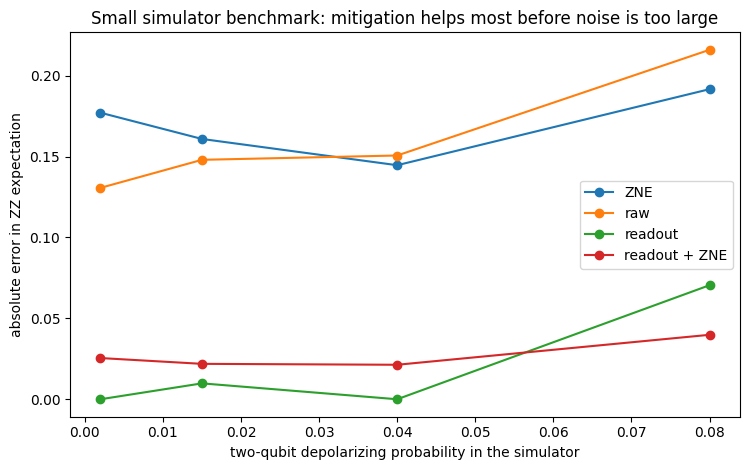

In [ ]:
fig, ax = plt.subplots(figsize=(7.6, 4.8))
for method, group in benchmark_df.groupby("method"):
    group = group.sort_values("two-qubit depolarizing probability")
    ax.plot(
        group["two-qubit depolarizing probability"],
        group["absolute error from ideal"],
        marker="o",
        label=method,
    )
ax.set_xlabel("two-qubit depolarizing probability in the simulator")
ax.set_ylabel("absolute error in ZZ expectation")
ax.set_title("Small simulator benchmark: mitigation helps most before noise is too large")
ax.legend()
fig.tight_layout()
fig.savefig(ASSET_DIR / "qem_mitigation_mini_benchmark.png", dpi=160)
plt.show()


The benchmark is intentionally small. It shows why QEM should be presented with uncertainty and limitations: mitigation can reduce bias in a moderate-noise regime, but extrapolation can become unreliable when the circuit is too noisy.


## 6. Error suppression, mitigation, and correction

**Error suppression** reduces errors before or during execution. Examples include transpilation optimization, dynamical decoupling, Pauli twirling, and measurement twirling.

**Error mitigation** post-processes data from extra experiments. Readout mitigation and ZNE are examples.

**Quantum error correction** encodes information into logical qubits and uses syndrome measurements to detect and correct errors during the computation. It is the route to fault tolerance, but it needs many more physical qubits and careful control than this tutorial uses.

Real workflows often use suppression and mitigation together. Neither should be described as a replacement for fault-tolerant quantum computing.


## 7. Optional: run a tiny error-mitigation experiment on IBM quantum hardware

This section is off by default. It uses Qiskit Runtime `EstimatorV2` with `mode=backend`, not a session. It reads `QISKIT_IBM_TOKEN` from the environment and does not save or print it.

Before enabling it, check your IBM Quantum usage and change `RUN_ON_IBM = True` only when you are ready. The default plan is one Bell-state circuit, two observables (`ZZ` and `XX`), 256 shots for a raw Estimator job, and a small readout-mitigated Estimator job. Mitigation settings can add calibration overhead.


In [ ]:
RUN_ON_IBM = False
IBM_SHOTS = 256


def run_ibm_estimator_optional(run_on_ibm: bool = RUN_ON_IBM, shots: int = IBM_SHOTS):
    """Optional hardware run written for qiskit-ibm-runtime 0.47.0."""
    if not run_on_ibm:
        print("RUN_ON_IBM is False; skipping the IBM hardware section.")
        return None

    import os
    from qiskit.quantum_info import SparsePauliOp
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
    from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2 as Estimator

    token = os.environ.get("QISKIT_IBM_TOKEN")
    instance = os.environ.get("QISKIT_IBM_INSTANCE")
    if not token:
        print("QISKIT_IBM_TOKEN is not set. The notebook remains in simulator-only mode.")
        return None

    service_kwargs = {"channel": "ibm_quantum_platform", "token": token}
    if instance:
        service_kwargs["instance"] = instance
    service = QiskitRuntimeService(**service_kwargs)

    backend = service.least_busy(operational=True, simulator=False, min_num_qubits=2)
    pass_manager = generate_preset_pass_manager(backend=backend, optimization_level=1)
    isa_circuit = pass_manager.run(make_bell_circuit())
    observables_ibm = [SparsePauliOp.from_list([("ZZ", 1.0)]), SparsePauliOp.from_list([("XX", 1.0)])]
    isa_observables = [observable.apply_layout(isa_circuit.layout) for observable in observables_ibm]

    print("Planned hardware run:")
    print("  circuits: 1 Bell-state circuit")
    print("  observables: ZZ and XX")
    print(f"  requested default shots per estimator job: {shots}")
    print("  jobs: one raw Estimator job and one readout-mitigated Estimator job")
    print("  token will not be printed or saved")

    raw_estimator = Estimator(mode=backend, options={"default_shots": shots, "resilience_level": 0})
    raw_result = raw_estimator.run([(isa_circuit, isa_observables)]).result()[0]

    mitigated_estimator = Estimator(mode=backend, options={"default_shots": shots, "resilience_level": 1})
    mitigated_estimator.options.resilience.measure_mitigation = True
    mitigated_estimator.options.resilience.measure_noise_learning.num_randomizations = 8
    mitigated_estimator.options.resilience.measure_noise_learning.shots_per_randomization = 16
    mitigated_result = mitigated_estimator.run([(isa_circuit, isa_observables)]).result()[0]

    return {
        "backend_name": backend.name,
        "observables": ["ZZ", "XX"],
        "raw_values": raw_result.data.evs,
        "raw_stds": raw_result.data.stds,
        "mitigated_values": mitigated_result.data.evs,
        "mitigated_stds": mitigated_result.data.stds,
    }


hardware_result = run_ibm_estimator_optional()
hardware_result


RUN_ON_IBM is False; skipping the IBM hardware section.


No IBM hardware results are included. If a contributor runs the optional cell, the post should state the backend, date, shot count, options, and result provenance. Do not paste tokens, private account names, or private job identifiers into the repository.


## Common mistakes

- Thinking mitigation removes all errors.
- Confusing mitigation with error correction.
- Ignoring the extra shots and calibration circuits.
- Using ZNE when the circuit is already too noisy.
- Trusting a mitigated value without uncertainty.
- Treating simulator results as hardware results.


## What to try next

- Increase the readout error and watch the assignment matrix become harder to invert.
- Change the gate-noise strength and see when ZNE begins to fail.
- Estimate a small Hamiltonian such as `0.5 ZI + 0.5 IZ + 0.3 XX`.
- Compare linear and exponential fits for ZNE.
- Run the optional IBM section only after checking your plan usage and shot budget.


## Contributor note

Contributor note: I first found quantum error mitigation approachable by starting with a simple question: if a quantum computer gives a noisy expectation value, can extra experiments and careful classical post-processing make the estimate less biased? Small circuits like the Bell-state example above are a good place to start before moving to larger algorithms.


## References

1. K. Temme, S. Bravyi, and J. M. Gambetta, "Error mitigation for short-depth quantum circuits," *Physical Review Letters* 119, 180509 (2017), arXiv:1612.02058.
2. Y. Li and S. C. Benjamin, "Efficient variational quantum simulator incorporating active error minimisation," *Physical Review X* 7, 021050 (2017), arXiv:1611.09301.
3. S. Endo, S. C. Benjamin, and Y. Li, "Practical quantum error mitigation for near-future applications," *Physical Review X* 8, 031027 (2018), arXiv:1712.09271.
4. T. Giurgica-Tiron, Y. Hindy, R. LaRose, A. Mari, and W. J. Zeng, "Digital zero noise extrapolation for quantum error mitigation," arXiv:2005.10921 (2020).
5. A. Kandala et al., "Error mitigation extends the computational reach of a noisy quantum processor," *Nature* 567, 491-495 (2019).
6. Qiskit documentation: https://quantum.cloud.ibm.com/docs
7. Qiskit Aer noise model documentation: https://qiskit.github.io/qiskit-aer/
8. IBM Quantum Runtime Estimator documentation: https://quantum.cloud.ibm.com/docs/api/qiskit-ibm-runtime/estimator-v2
9. IBM Quantum error mitigation and suppression documentation: https://quantum.cloud.ibm.com/docs/guides/error-mitigation-and-suppression-techniques
10. IBM Quantum Open Plan documentation: https://quantum.cloud.ibm.com/docs/guides/plans-overview



# What is Readout Error Mitigation?

Sometimes the quantum computer measures the wrong classical result.

For example:
- a true 0 may be reported as 1,
- or a true 1 may be reported as 0.

This is called readout error.

The notebook estimates these mistakes using calibration circuits.

It prepares known states such as:
- 00
- 01
- 10
- 11

and studies how often the measurement device reports incorrect values.

From this information, the notebook builds a correction model.

---

# Simple analogy

Imagine a thermometer that always reads 2 degrees too high.

If you know this bias exists, you can mathematically compensate for it.

Readout mitigation works similarly.

The notebook first learns how the detector makes mistakes, then uses that information to partially correct future measurements.



# What is Zero-Noise Extrapolation (ZNE)?

Zero-noise extrapolation is one of the most important quantum error mitigation techniques.

Instead of trying to directly remove noise, scientists:

1. intentionally increase the noise,
2. observe how the answer changes,
3. mathematically estimate what the answer would look like at zero noise.

---

# Simple analogy

Imagine listening to a song through:
- light static,
- medium static,
- heavy static.

By studying how the sound degrades, you may estimate what the original clean song sounded like.

Zero-noise extrapolation works similarly.

---

# What is gate folding?

Suppose a quantum gate is:

$
U
$

The notebook may replace it with:

$
U U^\dagger U
$

where:
- $U^\dagger\) is the inverse gate.

Ideally:

\[
U U^\dagger U = U
\]

So logically the circuit performs the same operation.

But physically:
- more gates are executed,
- more time passes,
- and more noise accumulates.

This artificially amplifies the noise level so the notebook can study how the result changes.



# Final Big Picture

Modern quantum computers are powerful but noisy.

Quantum error mitigation is one of the key techniques helping researchers use today's imperfect hardware more effectively.

This notebook demonstrates:
- how noise affects quantum circuits,
- how measurements become distorted,
- and how scientists estimate cleaner results using mitigation techniques.

Error mitigation does not magically remove all errors.

However, it is an extremely important bridge between:
- today's noisy quantum hardware,
- and future fault-tolerant quantum computers.
